# Yomi — PDI para OCR em scans de mangá com baixa qualidade

## Problema real

Mangás distribuídos como scans podem chegar ao leitor com contraste fraco, ruído de digitalização ou artefatos acumulados por recompressão. Para uma pessoa o texto ainda pode parecer legível, mas pequenas alterações nos traços japoneses afetam bastante o OCR.

> **Pergunta:** quando um scan chega com baixa qualidade, técnicas clássicas de PDI conseguem recuperar parte da precisão do OCR?

O leitor, a tradução, o dicionário, o furigana e o Anki são partes complementares. A contribuição avaliada aqui é a restauração dos pixels antes do reconhecimento.

## O papel do PDI

```text
SCAN LIMPO -----------------------→ OCR
SCAN COM PROBLEMA → sem PDI       → OCR
SCAN COM PROBLEMA → restauração   → OCR
```

Em uma página limpa, alterar os pixels sem necessidade pode até piorar o resultado. O PDI se torna útil quando responde a um defeito identificável da imagem.

## 1. Preparação

Use o kernel `Yomi PDI (Python 3.11)`. As visualizações abaixo são produzidas com OpenCV, NumPy e Pillow.

In [1]:
from pathlib import Path
import json
import os
import subprocess
import sys

import cv2
import numpy as np
from IPython.display import Markdown, display
from PIL import Image as PILImage

ROOT = Path.cwd().resolve()
if not (ROOT / 'backend').is_dir():
    ROOT = ROOT.parent
if not (ROOT / 'backend').is_dir():
    raise RuntimeError('Abra o notebook a partir da raiz do projeto ou de notebooks/.')

venv_python = Path('Scripts/python.exe') if os.name == 'nt' else Path('bin/python')
EXPECTED_PYTHON = ROOT / '.venv' / venv_python
if Path(sys.executable).resolve() != EXPECTED_PYTHON.resolve():
    raise RuntimeError(
        f'Kernel incorreto: {sys.executable}. Selecione Yomi PDI (Python 3.11).'
    )
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from backend.pipeline.robustness import degrade, restore

def show_bgr(image):
    rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    display(PILImage.fromarray(rgb))

def tile(label, image, width=400, height=560):
    if image.ndim == 2:
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    canvas = np.full((height, width, 3), 255, dtype=np.uint8)
    scale = min((width - 20) / image.shape[1], (height - 52) / image.shape[0])
    new_w = max(1, int(round(image.shape[1] * scale)))
    new_h = max(1, int(round(image.shape[0] * scale)))
    resized = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_AREA)
    x = (width - new_w) // 2
    y = 42 + (height - 48 - new_h) // 2
    canvas[y:y + new_h, x:x + new_w] = resized
    cv2.putText(canvas, label, (12, 27), cv2.FONT_HERSHEY_SIMPLEX,
                0.65, (25, 25, 25), 2, cv2.LINE_AA)
    return canvas

def comparison(items, width=400, height=560):
    return np.hstack([tile(label, image, width, height) for label, image in items])

print('Kernel correto:', sys.executable)
print('Raiz do projeto:', ROOT)

Kernel correto: /Users/matheusmedrado/PDI/yomi/.venv/bin/python
Raiz do projeto: /Users/matheusmedrado/PDI/yomi


## 2. Como tornamos a comparação reproduzível

Como as páginas de referência estão limpas, reproduzimos em software três defeitos encontrados em material de baixa qualidade. Os parâmetros e as sementes são fixos, permitindo repetir a comparação sem depender de dois scans diferentes.

| Condição reproduzida | Parâmetro do teste | Restauração | Conteúdo |
|---|---:|---|---|
| contraste muito baixo | faixa dinâmica de 5% | equalização de histograma | Lab 03 |
| ruído distribuído | $\sigma = 80$ | Gaussiano 3×3 | Lab 04 |
| ruído impulsivo | 10% dos pixels | mediana 3×3 | Lab 04 |

As intensidades são deliberadamente fortes: este é um teste de estresse controlado. A motivação vem de scans reais; os números abaixo medem os cenários definidos, não todos os mangás existentes.

## 3. Evidência visual em uma página inteira

A página 10 também é a página `03 / 04` dos CBZs de demonstração. O ruído impulsivo adiciona pontos pretos e brancos; a mediana substitui cada pixel pelo valor central de sua vizinhança 3×3.

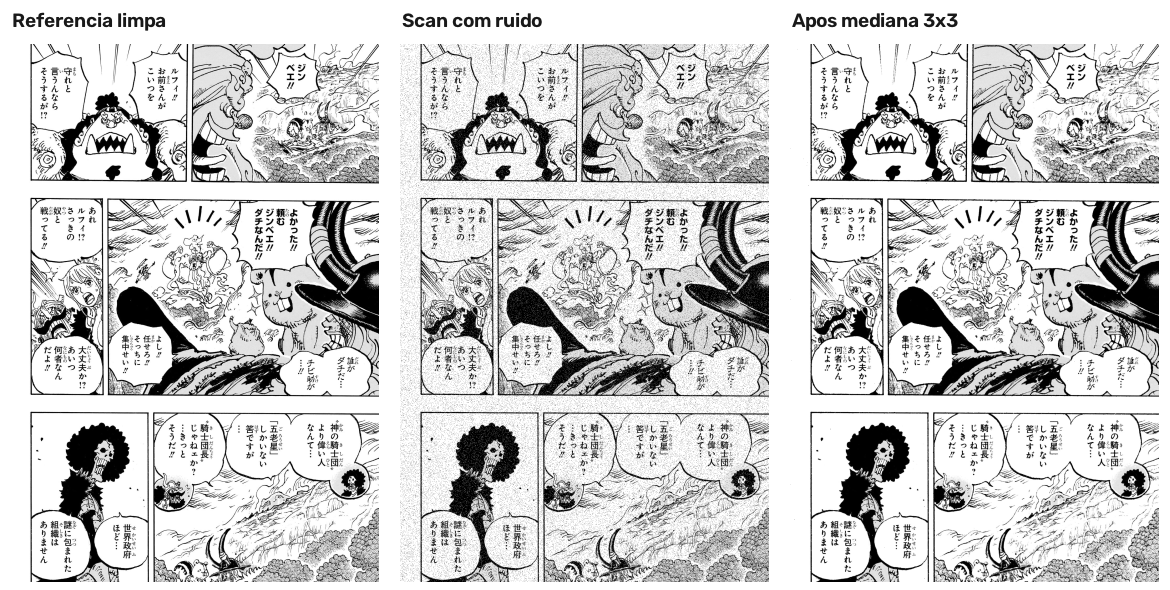

In [2]:
page_clean = cv2.imread(str(ROOT / 'sample' / '10.png'), cv2.IMREAD_COLOR)
if page_clean is None:
    raise FileNotFoundError(ROOT / 'sample' / '10.png')

page_noisy = degrade(page_clean, 'salt_pepper', seed=20260733)
page_median = restore(page_noisy, 'salt_pepper')
show_bgr(comparison([
    ('Referencia limpa', page_clean),
    ('Scan com ruido', page_noisy),
    ('Apos mediana 3x3', page_median),
], width=390, height=590))

## 4. Zoom: os pixels que chegam ao OCR

A página inteira torna o ruído visível; o zoom mostra por que ele confunde o reconhecimento dos pequenos traços. É o mesmo balão nos três caminhos.

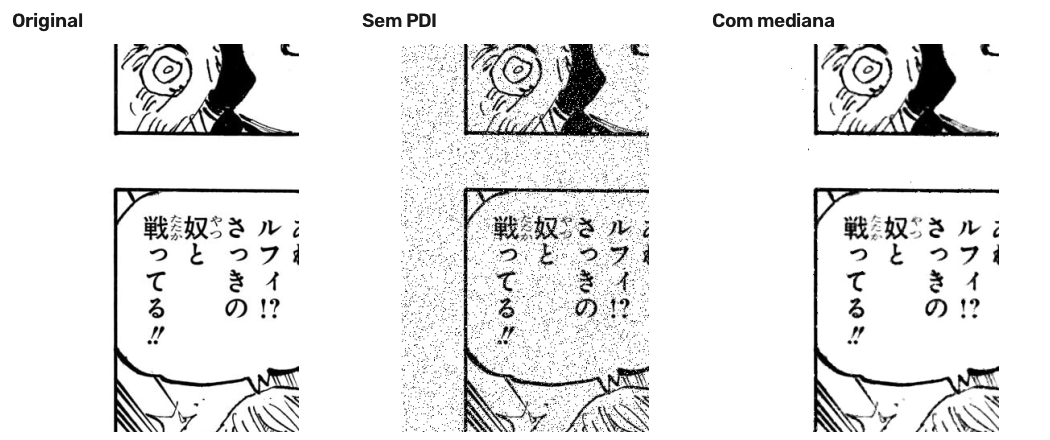

In [3]:
# Caixa anotada middle_panel_left_1, convertida de 1000x1500 para a página real.
ann_x, ann_y, ann_w, ann_h = 50, 350, 120, 250
sx, sy = page_clean.shape[1] / 1000, page_clean.shape[0] / 1500
x1, y1 = int(ann_x * sx), int(ann_y * sy)
x2, y2 = int((ann_x + ann_w) * sx), int((ann_y + ann_h) * sy)
pad = 70
x1, y1 = max(0, x1 - pad), max(0, y1 - pad)
x2, y2 = min(page_clean.shape[1], x2 + pad), min(page_clean.shape[0], y2 + pad)
crop_clean = page_clean[y1:y2, x1:x2]
crop_noisy = page_noisy[y1:y2, x1:x2]
crop_median = restore(crop_noisy, 'salt_pepper')
show_bgr(comparison([
    ('Original', crop_clean),
    ('Sem PDI', crop_noisy),
    ('Com mediana', crop_median),
], width=350, height=440))

### Efeito observado no reconhecimento

Na execução local da página inteira, o balão que contém a fala abaixo mudou de uma sequência bastante corrompida para uma leitura praticamente igual à referência:

| Caminho | Texto reconhecido |
|---|---|
| referência | `あれ ルフィ!? さっきの奴と戦ってる!!` |
| sem PDI | `あ．．．あなたのおまえ さっきの ええ．．．戦ってる` |
| com mediana | `あれ ルフィ！？ さっきの奴と戦ってる！` |

Considerando as regiões associadas dessa página, o CER caiu de aproximadamente **0,387 para 0,161**. Essa execução de página inteira apoia a demonstração; a avaliação principal abaixo mantém as caixas do detector fixas para isolar somente o efeito sobre o OCR.

## 5. Três problemas, três técnicas

Cada painel mostra o mesmo recorte em três estados: referência limpa, entrada problemática sem PDI e entrada restaurada com a técnica correspondente.

### Baixo contraste → equalização

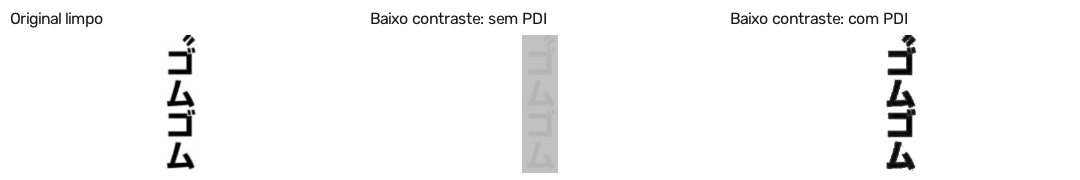

### Ruído gaussiano → filtro Gaussiano

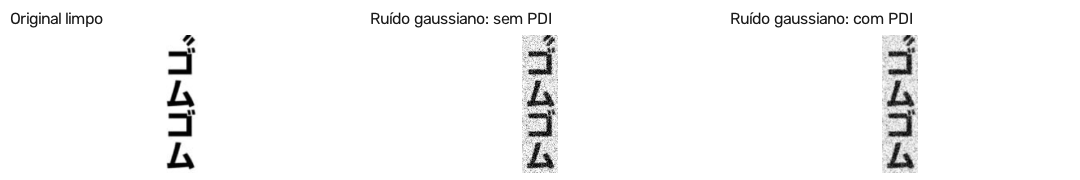

### Sal-e-pimenta → filtro da mediana

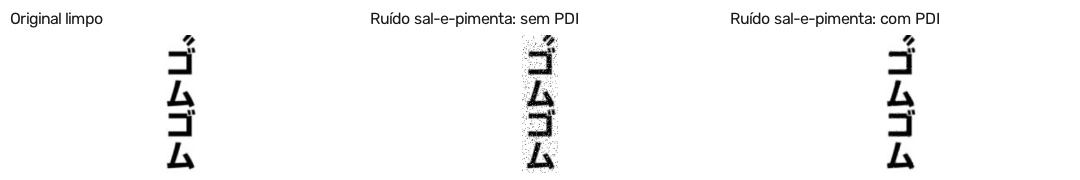

In [4]:
output_dir = ROOT / 'presentation_artifacts' / 'robustness'
evidence = [
    ('Baixo contraste → equalização', output_dir / 'evidence_low_contrast.png'),
    ('Ruído gaussiano → filtro Gaussiano', output_dir / 'evidence_gaussian_noise.png'),
    ('Sal-e-pimenta → filtro da mediana', output_dir / 'evidence_salt_pepper.png'),
]
for title, path in evidence:
    if not path.exists():
        raise FileNotFoundError(
            f'{path} não existe. Execute scripts/evaluate_robustness.py.'
        )
    display(Markdown(f'### {title}'))
    display(PILImage.open(path))

## 6. Histograma: por que a equalização ajuda?

No baixo contraste, os tons ficam comprimidos em uma faixa estreita. A equalização redistribui as intensidades, aumentando a separação entre papel e traços.

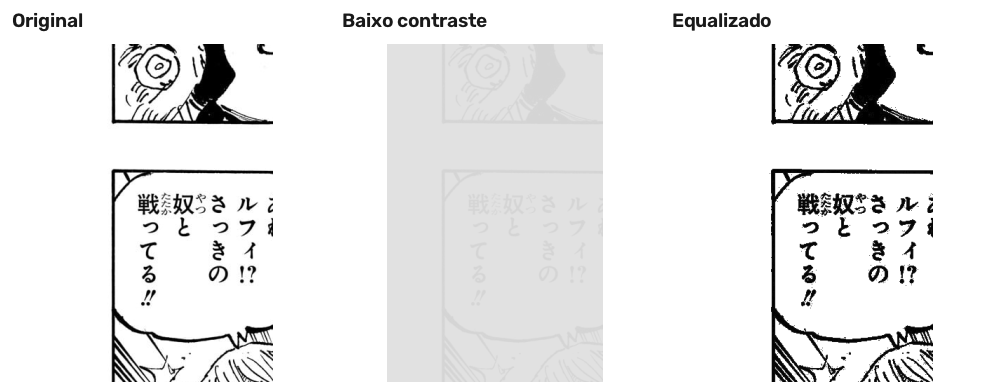

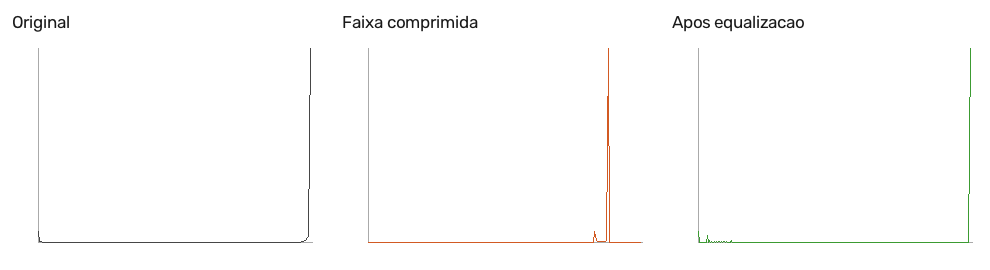

In [5]:
low_contrast = degrade(crop_clean, 'low_contrast', seed=0)
equalized = restore(low_contrast, 'low_contrast')
show_bgr(comparison([
    ('Original', crop_clean),
    ('Baixo contraste', low_contrast),
    ('Equalizado', equalized),
], width=330, height=390))

def histogram_panel(items, width=330, height=270):
    canvas = np.full((height, width * len(items), 3), 255, dtype=np.uint8)
    colors = [(70, 70, 70), (35, 90, 210), (50, 155, 60)]
    graph_top, graph_bottom = 48, height - 28
    graph_height = graph_bottom - graph_top
    for index, (label, image) in enumerate(items):
        offset = index * width
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        hist = cv2.calcHist([gray], [0], None, [256], [0, 256]).ravel()
        hist = hist / max(1.0, hist.max()) * graph_height
        cv2.putText(canvas, label, (offset + 12, 28),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.58, (25, 25, 25), 1, cv2.LINE_AA)
        cv2.line(canvas, (offset + 38, graph_top),
                 (offset + 38, graph_bottom), (170, 170, 170), 1)
        cv2.line(canvas, (offset + 38, graph_bottom),
                 (offset + width - 18, graph_bottom), (170, 170, 170), 1)
        usable = width - 58
        for level in range(1, 256):
            px1 = offset + 38 + int((level - 1) / 255 * usable)
            px2 = offset + 38 + int(level / 255 * usable)
            py1 = graph_bottom - int(hist[level - 1])
            py2 = graph_bottom - int(hist[level])
            cv2.line(canvas, (px1, py1), (px2, py2), colors[index], 1)
    return canvas

show_bgr(histogram_panel([
    ('Original', crop_clean),
    ('Faixa comprimida', low_contrast),
    ('Apos equalizacao', equalized),
]))

## 7. Avaliação quantitativa

O detector é executado uma vez por página. Depois comparamos OCR sem restauração e com PDI nas mesmas caixas e transcrições. Isso impede que uma diferença de localização favoreça um dos caminhos.

Foram anotadas 52 regiões nas páginas 08–11; 35 foram associadas às caixas do detector. A métrica é o **CER** (distância de edição por caractere): quanto menor, melhor.

In [6]:
# Para a apresentação, False reutiliza os resultados auditados imediatamente.
# Use True para executar novamente todo o OCR (~1-2 minutos em CPU).
RECALCULATE = False
results_path = output_dir / 'results.json'
if RECALCULATE or not results_path.exists():
    command = [
        sys.executable, str(ROOT / 'scripts' / 'evaluate_robustness.py'),
        '--output', str(output_dir),
    ]
    completed = subprocess.run(command, cwd=ROOT, text=True, capture_output=True)
    if completed.returncode != 0:
        raise RuntimeError(completed.stderr or completed.stdout)
    print(completed.stdout)
else:
    print('Reutilizando avaliação auditada:', results_path)

results = json.loads(results_path.read_text(encoding='utf-8'))

Reutilizando avaliação auditada: /Users/matheusmedrado/PDI/yomi/presentation_artifacts/robustness/results.json


In [7]:
display(Markdown((output_dir / 'report.md').read_text(encoding='utf-8')))

# Robustez do OCR com PDI

Detecção fixa; a degradação é aplicada somente aos mesmos recortes enviados ao OCR.

| Cenário | Sem PDI | Com PDI | Redução absoluta do CER |
|---|---:|---:|---:|
| Baixo contraste | 0.379 | 0.323 | +0.056 |
| Ruído gaussiano | 0.360 | 0.269 | +0.091 |
| Ruído sal-e-pimenta | 1.335 | 0.273 | +1.062 |

Cobertura fixa: 35/52 anotações associadas.
CER do material limpo: 0.257.

## 8. Resultado visual: CER sem e com PDI

A linha pontilhada representa o material limpo (`CER = 0,257`). As barras verdes mostram quanto cada técnica recuperou do desempenho perdido.

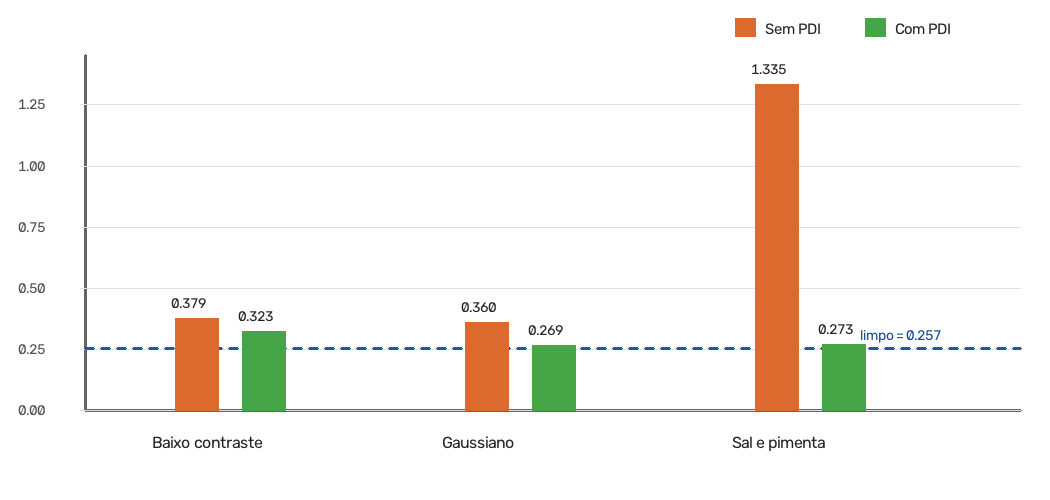

Baixo contraste: redução relativa de 14.7% no CER
Gaussiano: redução relativa de 25.2% no CER
Sal e pimenta: redução relativa de 79.5% no CER


In [8]:
aggregate = {row['variant']: row for row in results['aggregate']}
chart_rows = [
    ('Baixo contraste', aggregate['low_contrast_degraded']['cer_associated'],
     aggregate['low_contrast_restored']['cer_associated']),
    ('Gaussiano', aggregate['gaussian_noise_degraded']['cer_associated'],
     aggregate['gaussian_noise_restored']['cer_associated']),
    ('Sal e pimenta', aggregate['salt_pepper_degraded']['cer_associated'],
     aggregate['salt_pepper_restored']['cer_associated']),
]

def cer_chart(rows):
    width, height = 1050, 500
    canvas = np.full((height, width, 3), 255, dtype=np.uint8)
    left, top, bottom = 85, 55, 410
    max_cer = 1.45
    cv2.line(canvas, (left, top), (left, bottom), (100, 100, 100), 2)
    cv2.line(canvas, (left, bottom), (width - 30, bottom), (100, 100, 100), 2)
    for tick in (0.0, 0.25, 0.5, 0.75, 1.0, 1.25):
        y = bottom - int(tick / max_cer * (bottom - top))
        cv2.line(canvas, (left - 5, y), (width - 30, y), (225, 225, 225), 1)
        cv2.putText(canvas, f'{tick:.2f}', (18, y + 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.48, (80, 80, 80), 1, cv2.LINE_AA)
    clean_cer = aggregate['clean']['cer_associated']
    clean_y = bottom - int(clean_cer / max_cer * (bottom - top))
    for x in range(left, width - 30, 16):
        cv2.line(canvas, (x, clean_y), (min(x + 8, width - 30), clean_y),
                 (170, 90, 30), 2)
    cv2.putText(canvas, f'limpo = {clean_cer:.3f}', (width - 190, clean_y - 8),
                cv2.FONT_HERSHEY_SIMPLEX, 0.48, (150, 75, 20), 1, cv2.LINE_AA)
    centers = [230, 520, 810]
    for center, (label, without_pdi, with_pdi) in zip(centers, rows):
        for x, value, color in [
            (center - 55, without_pdi, (45, 105, 220)),
            (center + 12, with_pdi, (70, 165, 70)),
        ]:
            bar_height = int(value / max_cer * (bottom - top))
            cv2.rectangle(canvas, (x, bottom - bar_height),
                          (x + 43, bottom), color, -1)
            cv2.putText(canvas, f'{value:.3f}', (x - 4, bottom - bar_height - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.47, (35, 35, 35), 1, cv2.LINE_AA)
        cv2.putText(canvas, label, (center - 78, 448),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, (35, 35, 35), 1, cv2.LINE_AA)
    cv2.rectangle(canvas, (735, 18), (755, 36), (45, 105, 220), -1)
    cv2.putText(canvas, 'Sem PDI', (765, 34), cv2.FONT_HERSHEY_SIMPLEX,
                0.5, (35, 35, 35), 1, cv2.LINE_AA)
    cv2.rectangle(canvas, (865, 18), (885, 36), (70, 165, 70), -1)
    cv2.putText(canvas, 'Com PDI', (895, 34), cv2.FONT_HERSHEY_SIMPLEX,
                0.5, (35, 35, 35), 1, cv2.LINE_AA)
    return canvas

show_bgr(cer_chart(chart_rows))
for label, without_pdi, with_pdi in chart_rows:
    recovery = 100 * (without_pdi - with_pdi) / without_pdi
    print(f'{label}: redução relativa de {recovery:.1f}% no CER')

## 9. O resultado não depende de um único recorte

A tabela abaixo abre o agregado por página. Ela também evita uma conclusão exagerada: o efeito agregado é positivo nos três cenários, embora uma técnica possa piorar um caso isolado.

In [9]:
page_lookup = {(row['page'], row['variant']): row for row in results['pages']}
scenario_variants = [
    ('Baixo contraste', 'low_contrast'),
    ('Gaussiano', 'gaussian_noise'),
    ('Sal-e-pimenta', 'salt_pepper'),
]
lines = [
    '| Página | Cenário | Sem PDI | Com PDI | Efeito |',
    '|---|---|---:|---:|:---:|',
]
for page in ('08.png', '09.png', '10.png', '11.png'):
    for label, variant in scenario_variants:
        before = page_lookup[(page, f'{variant}_degraded')]
        after = page_lookup[(page, f'{variant}_restored')]
        cer_before = before['cer_sum_associated'] / max(1, before['associated'])
        cer_after = after['cer_sum_associated'] / max(1, after['associated'])
        effect = '↓ melhora' if cer_after < cer_before else '↑ piora'
        lines.append(
            f'| {page} | {label} | {cer_before:.3f} | {cer_after:.3f} | {effect} |'
        )
display(Markdown('\n'.join(lines)))

| Página | Cenário | Sem PDI | Com PDI | Efeito |
|---|---|---:|---:|:---:|
| 08.png | Baixo contraste | 0.730 | 0.543 | ↓ melhora |
| 08.png | Gaussiano | 0.587 | 0.540 | ↓ melhora |
| 08.png | Sal-e-pimenta | 1.501 | 0.506 | ↓ melhora |
| 09.png | Baixo contraste | 0.510 | 0.403 | ↓ melhora |
| 09.png | Gaussiano | 0.633 | 0.385 | ↓ melhora |
| 09.png | Sal-e-pimenta | 0.997 | 0.375 | ↓ melhora |
| 10.png | Baixo contraste | 0.222 | 0.275 | ↑ piora |
| 10.png | Gaussiano | 0.054 | 0.142 | ↑ piora |
| 10.png | Sal-e-pimenta | 1.625 | 0.198 | ↓ melhora |
| 11.png | Baixo contraste | 0.294 | 0.226 | ↓ melhora |
| 11.png | Gaussiano | 0.303 | 0.195 | ↓ melhora |
| 11.png | Sal-e-pimenta | 1.363 | 0.175 | ↓ melhora |

## Conclusão

- scans limpos devem permanecer intactos;
- contraste fraco pode ser tratado com equalização;
- ruído distribuído responde ao filtro Gaussiano;
- ruído impulsivo responde muito bem à mediana;
- nos três cenários agregados, o CER diminuiu com a restauração adequada.